In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('./data/annotated_filtered_col.CG_2.fast.tsv', sep='\t')      # or read_parquet / feather …
df

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
0,0,1,101,200,0.8951,350,41,6,False,False,False,False,0.8951
1,0,1,301,400,0.5487,62,51,2,False,False,False,False,0.5487
2,0,1,401,500,0.8246,47,10,1,False,False,False,False,0.8246
3,0,1,501,600,0.7206,98,38,3,False,False,False,False,0.7206
4,0,1,601,700,0.8982,203,23,6,False,False,False,False,0.8982
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5925984,16,5,26974801,26974900,0.8462,22,4,7,False,False,False,False,0.8462
5925985,16,5,26974901,26975000,0.7500,3,1,2,False,False,False,False,NaN
5925986,16,5,26975101,26975200,1.0000,4,0,4,False,False,False,False,NaN
5925987,16,5,26975201,26975300,1.0000,8,0,8,False,False,False,False,1.0000


In [3]:
dmw = pd.read_pickle("./data/dmw_robust.pkl")

In [4]:
calls = pd.read_pickle("./data/calls_robust.pkl")

In [5]:
dmw

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
0,1,5401,5500,13.760077,15,0.141937,11,1,0.102152,6,...,10.940558,14.0,1.536786,0.879921,0.930022,1.000000,0,True,ns_qval,euc_gene
1,1,7001,7100,55.949639,16,0.298853,14,9,0.220058,9,...,44.432533,15.0,1.536786,0.002540,0.016506,0.023845,0,False,no_neighbor_support,euc_gene
2,1,11201,11300,77.019910,16,0.443047,15,0,0.350130,12,...,20.305446,15.0,1.536786,0.000022,0.585855,0.000418,0,True,low_cov_hi_lo_and_loco_ns,euc_gene
3,1,23901,24000,19.171355,15,0.243401,3,4,0.156362,4,...,14.295747,14.0,1.536786,0.642780,0.811207,1.000000,1,True,ns_qval,euc_gene
4,1,24001,24100,21.045295,15,0.197810,14,2,0.150443,2,...,15.004330,14.0,1.536786,0.548825,0.779265,0.984130,2,True,ns_qval,euc_gene
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304685,5,15299801,15299900,18.546799,16,0.197922,12,1,0.136665,16,...,14.141530,15.0,1.544736,0.743535,0.869293,1.000000,1,True,ns_qval,het_te
304686,5,15299901,15300000,13.166474,16,0.189137,5,16,0.077046,3,...,9.454273,15.0,1.544736,0.931736,0.977655,1.000000,0,True,ns_qval,het_te
304687,5,15300001,15300100,14.476215,16,0.200705,7,1,0.129774,8,...,7.914641,15.0,1.544736,0.897338,0.991027,1.000000,0,True,ns_qval,het_te
304688,5,15300201,15300300,16.898293,16,0.133333,13,8,0.110645,8,...,10.744740,15.0,1.544736,0.813218,0.958867,1.000000,0,True,ns_qval,het_te


In [6]:
calls

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
0,1,24301,24400,63.303077,16,0.323758,0,15,0.235239,15,...,33.888008,15.0,1.536786,5.201946e-04,1.064678e-01,6.429773e-03,1,True,ok,euc_gene
1,1,25801,25900,68.401063,16,0.283734,0,16,0.233424,9,...,58.003879,15.0,1.536786,1.649916e-04,9.844080e-04,2.425366e-03,2,False,ok,euc_gene
2,1,26601,26700,54.791427,16,0.340057,0,12,0.204524,12,...,27.864254,15.0,1.536786,3.231771e-03,2.558146e-01,2.900470e-02,2,True,ok,euc_gene
3,1,117101,117200,95.418897,16,0.454657,15,0,0.324092,15,...,69.541184,15.0,1.536786,2.317766e-07,6.989049e-05,7.101292e-06,1,False,ok,euc_gene
4,1,117201,117300,209.579299,16,0.469321,16,0,0.315957,16,...,130.321252,15.0,1.536786,0.000000e+00,9.155010e-12,0.000000e+00,1,False,ok,euc_gene
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7202,5,15152401,15152500,76.102981,16,0.345352,15,2,0.291096,0,...,62.357804,15.0,1.544736,2.998746e-05,3.989609e-04,1.631343e-03,1,False,ok,het_te
7203,5,15182201,15182300,124.173308,16,0.394110,16,7,0.264723,7,...,102.892617,15.0,1.544736,1.418309e-10,1.782187e-08,4.899795e-08,1,False,ok,het_te
7204,5,15203801,15203900,73.960816,16,0.356692,15,10,0.289099,10,...,61.158534,15.0,1.544736,4.961880e-05,5.225181e-04,2.429303e-03,1,False,ok,het_te
7205,5,15259701,15259800,70.739222,16,0.413612,8,6,0.340276,6,...,58.261694,15.0,1.544736,1.047749e-04,9.935832e-04,4.410364e-03,1,False,ok,het_te


In [8]:
df[(df['chr']==5) & (df['start']==21691101)] #& (df['cluster']==8)]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
346052,0,5,21691101,21691200,0.3421,39,75,2,True,False,False,False,0.3421
700389,1,5,21691101,21691200,0.4356,44,57,2,True,False,False,False,0.4356
1054349,2,5,21691101,21691200,0.3721,16,27,2,True,False,False,False,0.3721
1407987,3,5,21691101,21691200,0.6364,14,8,2,True,False,False,False,0.6364
1762035,4,5,21691101,21691200,0.0625,3,45,2,True,False,False,False,0.0625
2115186,5,5,21691101,21691200,0.6500,13,7,2,True,False,False,False,0.6500
2468989,6,5,21691101,21691200,0.4333,13,17,2,True,False,False,False,0.4333
2822727,7,5,21691101,21691200,0.0588,2,32,2,True,False,False,False,0.0588
3174577,8,5,21691101,21691200,0.5000,5,5,2,True,False,False,False,0.5000
3524653,9,5,21691101,21691200,0.7273,8,3,2,True,False,False,False,0.7273


In [5]:

#AT5G53450
dmw[(dmw['chr']==5) & (dmw['start']>=21689801)]

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
127100,5,21689801,21689900,92.114427,16,0.502153,15,7,0.248038,7,...,48.732891,15.0,1.536786,5.357659e-07,0.007047,0.000015,2,False,ok,euc_gene
127101,5,21689901,21690000,61.347242,16,0.327902,15,7,0.213495,7,...,43.575580,15.0,1.536786,8.000215e-04,0.019450,0.009205,2,False,ok,euc_gene
127102,5,21690001,21690100,34.821735,16,0.273746,2,7,0.164740,7,...,19.069016,15.0,1.536786,1.231642e-01,0.647892,0.434030,1,True,ns_qval,euc_gene
127103,5,21690201,21690300,39.390537,16,0.300156,5,7,0.114057,7,...,22.887140,15.0,1.536786,5.943474e-02,0.459162,0.265532,0,True,ns_qval,euc_gene
127104,5,21690501,21690600,76.075976,16,0.312061,6,7,0.200081,7,...,51.200912,15.0,1.536786,2.749782e-05,0.004242,0.000509,1,False,ok,euc_gene
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187858,5,26893101,26893200,78.143690,16,0.432695,5,10,0.192888,10,...,47.242508,15.0,1.527399,1.494797e-05,0.008976,0.000556,1,False,weak_effect,euc_te
187859,5,26893201,26893300,24.144295,12,0.165110,2,12,0.146240,12,...,18.220273,11.0,1.527399,2.002148e-01,0.369007,0.648012,2,True,ns_qval,euc_te
187860,5,26893301,26893400,45.335038,14,0.226978,6,16,0.168040,5,...,31.544523,13.0,1.527399,8.441302e-03,0.080093,0.085656,0,True,ns_qval,euc_te
187861,5,26893401,26893500,16.558965,15,0.183134,2,6,0.086398,6,...,10.132939,14.0,1.527399,7.637622e-01,0.947898,1.000000,1,True,ns_qval,euc_te


In [10]:
dmw.loc[127100]

chr                          5
start                 21689801
end                   21689900
X2                   92.114427
df                          16
delta_max             0.502153
hi_cluster                  15
lo_cluster                   7
delta_max_trim        0.248038
top_cluster                  7
top_cov                    127
m_hi                      24.0
m_lo                     127.0
X2_loco              48.732891
df_loco                   15.0
phi                   1.536786
pval                  0.000001
p_loco                0.007047
qval                  0.000015
neighbor_support             2
dominance_blocked        False
reason                      ok
category              euc_gene
Name: 127100, dtype: object

In [6]:
dmw.loc[127101]

chr                          5
start                 21689901
end                   21690000
X2                   61.347242
df                          16
delta_max             0.327902
hi_cluster                  15
lo_cluster                   7
delta_max_trim        0.213495
top_cluster                  7
top_cov                     96
m_hi                       9.0
m_lo                      96.0
X2_loco               43.57558
df_loco                   15.0
phi                   1.536786
pval                    0.0008
p_loco                 0.01945
qval                  0.009205
neighbor_support             2
dominance_blocked        False
reason                      ok
category              euc_gene
Name: 127101, dtype: object

In [8]:
dmw.loc[127102]

chr                          5
start                 21690001
end                   21690100
X2                   34.821735
df                          16
delta_max             0.273746
hi_cluster                   2
lo_cluster                   7
delta_max_trim         0.16474
top_cluster                  7
top_cov                     30
m_hi                      29.0
m_lo                      30.0
X2_loco              19.069016
df_loco                   15.0
phi                   1.536786
pval                  0.123164
p_loco                0.647892
qval                   0.43403
neighbor_support             1
dominance_blocked         True
reason                 ns_qval
category              euc_gene
Name: 127102, dtype: object

In [9]:
dmw.loc[127103]

chr                          5
start                 21690201
end                   21690300
X2                   39.390537
df                          16
delta_max             0.300156
hi_cluster                   5
lo_cluster                   7
delta_max_trim        0.114057
top_cluster                  7
top_cov                    184
m_hi                     109.0
m_lo                     184.0
X2_loco               22.88714
df_loco                   15.0
phi                   1.536786
pval                  0.059435
p_loco                0.459162
qval                  0.265532
neighbor_support             0
dominance_blocked         True
reason                 ns_qval
category              euc_gene
Name: 127103, dtype: object

In [11]:
dmw.loc[127104]

chr                          5
start                 21690501
end                   21690600
X2                   76.075976
df                          16
delta_max             0.312061
hi_cluster                   6
lo_cluster                   7
delta_max_trim        0.200081
top_cluster                  7
top_cov                    110
m_hi                     135.0
m_lo                     110.0
X2_loco              51.200912
df_loco                   15.0
phi                   1.536786
pval                  0.000027
p_loco                0.004242
qval                  0.000509
neighbor_support             1
dominance_blocked        False
reason                      ok
category              euc_gene
Name: 127104, dtype: object

In [7]:
dmw.iloc[85]

chr                                    1
start                              77801
end                                77900
X2                            283.205748
df                                    16
delta_max                       0.509852
hi_cluster                            16
lo_cluster                             0
delta_max_trim                  0.258787
top_cluster                           16
top_cov                                7
m_hi                                 7.0
m_lo                               355.0
X2_loco                        56.145545
df_loco                             15.0
phi                             1.536786
pval                                 0.0
p_loco                          0.001479
qval                                 0.0
neighbor_support                       0
dominance_blocked                  False
reason               no_neighbor_support
category                        euc_gene
Name: 85, dtype: object

In [8]:
calls

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
0,1,24301,24400,63.303077,16,0.323758,0,15,0.235239,15,...,33.888008,15.0,1.536786,5.201946e-04,1.064678e-01,6.429773e-03,1,True,ok,euc_gene
1,1,25801,25900,68.401063,16,0.283734,0,16,0.233424,9,...,58.003879,15.0,1.536786,1.649916e-04,9.844080e-04,2.425366e-03,2,False,ok,euc_gene
2,1,26601,26700,54.791427,16,0.340057,0,12,0.204524,12,...,27.864254,15.0,1.536786,3.231771e-03,2.558146e-01,2.900470e-02,2,True,ok,euc_gene
3,1,117101,117200,95.418897,16,0.454657,15,0,0.324092,15,...,69.541184,15.0,1.536786,2.317766e-07,6.989049e-05,7.101292e-06,1,False,ok,euc_gene
4,1,117201,117300,209.579299,16,0.469321,16,0,0.315957,16,...,130.321252,15.0,1.536786,0.000000e+00,9.155010e-12,0.000000e+00,1,False,ok,euc_gene
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7202,5,15152401,15152500,76.102981,16,0.345352,15,2,0.291096,0,...,62.357804,15.0,1.544736,2.998746e-05,3.989609e-04,1.631343e-03,1,False,ok,het_te
7203,5,15182201,15182300,124.173308,16,0.394110,16,7,0.264723,7,...,102.892617,15.0,1.544736,1.418309e-10,1.782187e-08,4.899795e-08,1,False,ok,het_te
7204,5,15203801,15203900,73.960816,16,0.356692,15,10,0.289099,10,...,61.158534,15.0,1.544736,4.961880e-05,5.225181e-04,2.429303e-03,1,False,ok,het_te
7205,5,15259701,15259800,70.739222,16,0.413612,8,6,0.340276,6,...,58.261694,15.0,1.544736,1.047749e-04,9.935832e-04,4.410364e-03,1,False,ok,het_te


In [34]:
df[(df['start']>=21327001)  & (df['chr']==1)]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
61558,0,1,21328401,21328500,0.7649,257,79,8,True,False,False,False,0.7649
61559,0,1,21328501,21328600,0.8556,77,13,2,True,False,False,False,0.8556
61560,0,1,21328601,21328700,0.4800,120,130,6,True,False,False,False,0.4800
61561,0,1,21328701,21328800,0.0794,5,58,2,True,False,False,False,0.0794
61562,0,1,21328901,21329000,0.7465,374,127,10,True,False,False,False,0.7465
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5667291,16,1,30426901,30427000,0.9167,22,2,4,False,False,False,False,0.9167
5667292,16,1,30427001,30427100,1.0000,4,0,2,False,False,False,False,NaN
5667293,16,1,30427101,30427200,0.7500,12,4,6,False,False,False,False,0.7500
5667294,16,1,30427201,30427300,1.0000,5,0,3,False,False,False,False,1.0000


In [32]:
#AT1G57590
df[(df['start']==21328401)  & (df['chr']==1)]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
61558,0,1,21328401,21328500,0.7649,257,79,8,True,False,False,False,0.7649
415910,1,1,21328401,21328500,0.6847,278,128,8,True,False,False,False,0.6847
770164,2,1,21328401,21328500,0.8054,120,29,8,True,False,False,False,0.8054
1124039,3,1,21328401,21328500,0.8770,107,15,8,True,False,False,False,0.8770
1477777,4,1,21328401,21328500,0.7664,105,32,8,True,False,False,False,0.7664
1831620,5,1,21328401,21328500,0.8846,69,9,8,True,False,False,False,0.8846
2184900,6,1,21328401,21328500,0.6887,73,33,8,True,False,False,False,0.6887
2538727,7,1,21328401,21328500,0.8305,98,20,8,True,False,False,False,0.8305
2892070,8,1,21328401,21328500,0.7436,58,20,8,True,False,False,False,0.7436
3243535,9,1,21328401,21328500,0.5526,21,17,8,True,False,False,False,0.5526


In [35]:
#AT1G57590
dmw[(dmw['start']==21328401)  & (dmw['chr']==1)] # max x^2 = 60

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
24606,1,21328401,21328500,81.411348,16,0.41637,3,10,0.28386,10,...,60.34944,15.0,1.536786,0.000008,0.000584,0.000164,1,False,ok,euc_gene


In [91]:
dmw.loc[24606]

chr                          1
start                 21328401
end                   21328500
X2                   81.411348
df                          16
delta_max              0.41637
hi_cluster                   3
lo_cluster                  10
delta_max_trim         0.28386
top_cluster                 10
top_cov                     15
m_hi                     122.0
m_lo                      15.0
X2_loco               60.34944
df_loco                   15.0
phi                   1.536786
pval                  0.000008
p_loco                0.000584
qval                  0.000164
neighbor_support             1
dominance_blocked        False
reason                      ok
category              euc_gene
Name: 24606, dtype: object

In [48]:
#AT2G33380
df[(df['start']>=14144800)  & (df['chr']==2)].iloc[:16]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
135401,0,2,14145101,14145200,0.8300,166,34,4,True,False,False,False,0.8300
135402,0,2,14145201,14145300,0.8209,110,24,4,True,False,False,False,0.8209
135403,0,2,14145301,14145400,0.7786,299,85,10,True,False,False,False,0.7786
135404,0,2,14145401,14145500,0.3956,89,136,4,True,False,False,False,0.3956
135405,0,2,14149101,14149200,0.0217,3,135,4,True,False,False,False,0.0217
135406,0,2,14152001,14152100,0.9006,462,51,10,True,False,False,False,0.9006
135407,0,2,14152601,14152700,0.7008,274,117,8,True,False,False,False,0.7008
135408,0,2,14152701,14152800,0.4164,112,157,4,True,False,False,False,0.4164
135409,0,2,14152801,14152900,0.1489,46,263,4,True,False,False,False,0.1489
135410,0,2,14153501,14153600,0.0076,2,261,6,True,False,False,False,0.0076


In [39]:
#AT2G33380
dmw[(dmw['start']>=14145000) & (dmw['chr']==2)].iloc[:4] # max x^2 = 41

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
49388,2,14145101,14145200,41.354287,16,0.353037,7,16,0.174032,16,...,21.489041,15.0,1.536786,0.042499,0.526811,0.209710,1,True,ns_qval,euc_gene
49389,2,14145201,14145300,34.535738,16,0.346423,4,16,0.217079,16,...,19.343365,15.0,1.536786,0.128574,0.634172,0.446020,2,True,ns_qval,euc_gene
49390,2,14145301,14145400,59.766673,16,0.389388,4,16,0.163089,16,...,41.155783,15.0,1.536786,0.001128,0.030577,0.012235,2,False,weak_effect,euc_gene
49391,2,14145401,14145500,15.934159,16,0.215698,13,0,0.186491,9,...,11.479220,15.0,1.536786,0.846689,0.943285,1.000000,1,True,ns_qval,euc_gene


In [94]:
dmw.loc[49390]

chr                            2
start                   14145301
end                     14145400
X2                     59.766673
df                            16
delta_max               0.389388
hi_cluster                     4
lo_cluster                    16
delta_max_trim          0.163089
top_cluster                   16
top_cov                       30
m_hi                       128.0
m_lo                        30.0
X2_loco                41.155783
df_loco                     15.0
phi                     1.536786
pval                    0.001128
p_loco                  0.030577
qval                    0.012235
neighbor_support               2
dominance_blocked          False
reason               weak_effect
category                euc_gene
Name: 49390, dtype: object

In [56]:
#AT3G55610
df[(df['start']>=20624000)  & (df['chr']==3)].iloc[:14]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
212309,0,3,20625501,20625600,0.1578,71,379,8,True,False,False,False,0.1578
212310,0,3,20625601,20625700,0.7683,63,19,2,True,False,False,False,0.7683
212311,0,3,20625701,20625800,0.8780,216,30,4,True,False,False,False,0.8780
212312,0,3,20625901,20626000,0.8983,106,12,2,True,False,False,False,0.8983
212313,0,3,20626001,20626100,0.0078,1,128,2,True,False,False,False,0.0078
212314,0,3,20626101,20626200,0.9284,415,32,8,True,False,False,False,0.9284
212315,0,3,20626201,20626300,0.8657,232,36,4,True,False,False,False,0.8657
212316,0,3,20626301,20626400,0.8462,99,18,2,True,False,False,False,0.8462
212317,0,3,20626501,20626600,0.1881,73,315,10,True,False,False,False,0.1881
212318,0,3,20626701,20626800,0.9032,112,12,2,True,False,False,False,0.9032


In [61]:
#AT3G55610
dmw[(dmw['start']>=20624000) & (dmw['chr']==3)].iloc[:13] # max x^2 = 32

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
79577,3,20625501,20625600,9.539805,16,0.271267,16,1,0.208946,9,...,7.927412,15.0,1.536786,0.985693,0.990698,1.000000,0,True,ns_qval,euc_gene
79578,3,20625601,20625700,35.578408,16,0.254555,7,10,0.149252,1,...,27.731883,15.0,1.536786,0.109752,0.260287,0.402179,2,True,ns_qval,euc_gene
79579,3,20625701,20625800,27.100651,16,0.274813,5,16,0.169148,5,...,19.321538,15.0,1.536786,0.345722,0.635265,0.795785,0,True,ns_qval,euc_gene
79580,3,20625901,20626000,18.999810,16,0.280916,4,15,0.217370,9,...,11.654031,15.0,1.536786,0.718612,0.939398,1.000000,1,True,ns_qval,euc_gene
79581,3,20626001,20626100,41.425068,16,0.462062,14,0,0.306484,14,...,10.763874,15.0,1.536786,0.041979,0.957535,0.207886,2,True,ns_qval,euc_gene
79582,3,20626101,20626200,43.049551,16,0.316658,4,10,0.197046,10,...,32.710406,15.0,1.536786,0.031509,0.127970,0.169180,2,True,ns_qval,euc_gene
79583,3,20626201,20626300,17.353089,16,0.216139,0,15,0.176639,15,...,11.561488,15.0,1.536786,0.791125,0.941476,1.000000,2,True,ns_qval,euc_gene
79584,3,20626301,20626400,19.395501,16,0.225302,1,12,0.199237,12,...,15.760987,15.0,1.536786,0.700253,0.803347,1.000000,1,True,ns_qval,euc_gene
79585,3,20626501,20626600,7.117933,16,0.253435,11,1,0.204270,11,...,4.180548,15.0,1.536786,0.997302,0.999782,1.000000,0,True,ns_qval,euc_gene
79586,3,20626701,20626800,13.671300,16,0.220669,0,15,0.195166,10,...,11.184635,15.0,1.536786,0.917633,0.949473,1.000000,1,True,ns_qval,euc_gene


In [90]:
dmw.loc[79582]

chr                          3
start                 20626101
end                   20626200
X2                   43.049551
df                          16
delta_max             0.316658
hi_cluster                   4
lo_cluster                  10
delta_max_trim        0.197046
top_cluster                 10
top_cov                     11
m_hi                     182.0
m_lo                      11.0
X2_loco              32.710406
df_loco                   15.0
phi                   1.536786
pval                  0.031509
p_loco                 0.12797
qval                   0.16918
neighbor_support             2
dominance_blocked         True
reason                 ns_qval
category              euc_gene
Name: 79582, dtype: object

In [66]:
#AT4G13575
df[(df['start']>=7892300)  & (df['chr']==4)].iloc[:6]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
257017,0,4,7892301,7892400,0.2920,40,97,4,True,False,False,False,0.2920
257018,0,4,7892501,7892600,0.2208,17,60,4,True,False,False,False,0.2208
257019,0,4,7892601,7892700,0.3095,13,29,4,True,False,True,False,0.3095
257020,0,4,7892901,7893000,0.0488,2,39,2,True,False,False,False,0.0488
257021,0,4,7893401,7893500,0.0067,2,295,6,True,False,False,False,0.0067
257022,0,4,7893601,7893700,0.0952,59,561,12,True,False,False,False,0.0952


In [82]:
#AT4G13575
dmw[(dmw['start']>=7892300) & (dmw['chr']==4)].iloc[:6] #max X^2 = 58

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
87531,4,7892301,7892400,75.054414,15,0.425094,5,0,0.308937,5,...,58.970237,14.0,1.536786,1.860941e-05,0.000456,3.614894e-04,0,False,no_neighbor_support,euc_gene
87532,4,7892501,7892600,101.567237,14,0.511861,13,1,0.312622,1,...,57.052257,13.0,1.536786,9.764885e-09,0.000396,3.939499e-07,1,False,ok,euc_gene
87533,4,7892601,7892700,80.819012,14,0.480397,6,1,0.258836,1,...,42.971641,13.0,1.536786,2.233874e-06,0.009161,5.459780e-05,1,False,ok,euc_gene
87534,4,7892901,7893000,24.269268,15,0.368579,12,1,0.270052,12,...,7.631161,14.0,1.536786,3.959934e-01,0.986285,8.509078e-01,0,True,ns_qval,euc_gene
87535,4,7893401,7893500,59.567512,16,0.348821,15,0,0.259597,15,...,24.584847,15.0,1.536786,1.177352e-03,0.382213,1.267445e-02,0,True,no_neighbor_support,euc_gene
87536,4,7893601,7893700,91.774374,16,0.185701,16,1,0.154027,6,...,43.559566,15.0,1.536786,5.837467e-07,0.019509,1.638836e-05,0,False,weak_effect,euc_gene


In [89]:
dmw.loc[87531]

chr                                    4
start                            7892301
end                              7892400
X2                             75.054414
df                                    15
delta_max                       0.425094
hi_cluster                             5
lo_cluster                             0
delta_max_trim                  0.308937
top_cluster                            5
top_cov                               22
m_hi                                22.0
m_lo                               137.0
X2_loco                        58.970237
df_loco                             14.0
phi                             1.536786
pval                            0.000019
p_loco                          0.000456
qval                            0.000361
neighbor_support                       0
dominance_blocked                  False
reason               no_neighbor_support
category                        euc_gene
Name: 87531, dtype: object

In [78]:
#AT5G53450
df[(df['start']>=21688700)  & (df['chr']==5)].iloc[:19]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
346042,0,5,21689701,21689800,0.4377,151,194,8,True,False,False,False,0.4377
346043,0,5,21689801,21689900,0.3540,97,177,6,True,False,False,False,0.3540
346044,0,5,21689901,21690000,0.4797,118,128,4,True,False,False,False,0.4797
346045,0,5,21690001,21690100,0.6829,84,39,2,True,False,False,False,0.6829
346046,0,5,21690201,21690300,0.4547,236,283,8,True,False,False,False,0.4547
346047,0,5,21690501,21690600,0.6756,379,182,10,True,False,False,False,0.6756
346048,0,5,21690601,21690700,0.3451,98,186,4,True,False,False,False,0.3451
346049,0,5,21690701,21690800,0.8167,98,22,2,True,False,False,False,0.8167
346050,0,5,21690801,21690900,0.4296,116,154,6,True,False,False,False,0.4296
346051,0,5,21690901,21691000,0.5300,247,219,8,True,False,False,False,0.5300


In [85]:
#AT5G53450
dmw[(dmw['start']>=21688700) & (dmw['chr']==5)].iloc[:19] # max x^2=51

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
127099,5,21689701,21689800,56.237460,16,0.379790,14,7,0.223158,7,...,37.292637,15.0,1.536786,2.390979e-03,0.060702,0.022684,1,True,low_cov_hi_lo_and_loco_ns,euc_gene
127100,5,21689801,21689900,92.114427,16,0.502153,15,7,0.248038,7,...,48.732891,15.0,1.536786,5.357659e-07,0.007047,0.000015,2,False,ok,euc_gene
127101,5,21689901,21690000,61.347242,16,0.327902,15,7,0.213495,7,...,43.575580,15.0,1.536786,8.000215e-04,0.019450,0.009205,2,False,ok,euc_gene
127102,5,21690001,21690100,34.821735,16,0.273746,2,7,0.164740,7,...,19.069016,15.0,1.536786,1.231642e-01,0.647892,0.434030,1,True,ns_qval,euc_gene
127103,5,21690201,21690300,39.390537,16,0.300156,5,7,0.114057,7,...,22.887140,15.0,1.536786,5.943474e-02,0.459162,0.265532,0,True,ns_qval,euc_gene
127104,5,21690501,21690600,76.075976,16,0.312061,6,7,0.200081,7,...,51.200912,15.0,1.536786,2.749782e-05,0.004242,0.000509,1,False,ok,euc_gene
127105,5,21690601,21690700,30.334571,16,0.340500,15,7,0.243773,7,...,20.504279,15.0,1.536786,2.322081e-01,0.575876,0.640373,2,True,ns_qval,euc_gene
127106,5,21690701,21690800,32.694457,16,0.300744,1,16,0.175861,7,...,24.992275,15.0,1.536786,1.681963e-01,0.364811,0.529250,2,True,ns_qval,euc_gene
127107,5,21690801,21690900,35.588039,16,0.307429,9,2,0.191383,2,...,26.420440,15.0,1.536786,1.095899e-01,0.307516,0.401765,1,True,ns_qval,euc_gene
127108,5,21690901,21691000,24.834150,16,0.198722,15,7,0.112535,7,...,14.448549,15.0,1.536786,4.418647e-01,0.855590,0.895639,1,True,ns_qval,euc_gene


In [88]:
dmw.loc[127104]

chr                          5
start                 21690501
end                   21690600
X2                   76.075976
df                          16
delta_max             0.312061
hi_cluster                   6
lo_cluster                   7
delta_max_trim        0.200081
top_cluster                  7
top_cov                    110
m_hi                     135.0
m_lo                     110.0
X2_loco              51.200912
df_loco                   15.0
phi                   1.536786
pval                  0.000027
p_loco                0.004242
qval                  0.000509
neighbor_support             1
dominance_blocked        False
reason                      ok
category              euc_gene
Name: 127104, dtype: object

In [87]:
df[(df['start']==21690501)  & (df['chr']==5)]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
346047,0,5,21690501,21690600,0.6756,379,182,10,True,False,False,False,0.6756
700384,1,5,21690501,21690600,0.7084,345,142,10,True,False,False,False,0.7084
1054344,2,5,21690501,21690600,0.7456,126,43,10,True,False,False,False,0.7456
1407982,3,5,21690501,21690600,0.6383,90,51,10,True,False,False,False,0.6383
1762030,4,5,21690501,21690600,0.6938,145,64,10,True,False,False,False,0.6938
2115181,5,5,21690501,21690600,0.8553,65,11,10,True,False,False,False,0.8553
2468984,6,5,21690501,21690600,0.8519,115,20,10,True,False,False,False,0.8519
2822722,7,5,21690501,21690600,0.4909,54,56,10,True,False,False,False,0.4909
3174572,8,5,21690501,21690600,0.7927,65,17,10,True,False,False,False,0.7927
3524648,9,5,21690501,21690600,0.6806,49,23,10,True,False,False,False,0.6806


In [98]:
import numpy as np
import pandas as pd

def select_dmws(
    dmw,
    # base gate
    q_alpha=0.02,
    p_loco_alpha=0.05,
    delta_trim_min=0.15,
    # main path
    neighbor_min_main=1,
    m_floor_main=10,
    # rescue path
    rescue_delta=0.255,
    rescue_m_hi=7,
    rescue_m_lo=50,
    # consensus path
    neighbor_min_consensus=2,
    m_floor_consensus=20,
):
    dmw = dmw.copy()

    base = (
        (dmw['qval'] <= q_alpha) &
        (dmw['p_loco'] <= p_loco_alpha) &
        (dmw['delta_max_trim'] >= delta_trim_min)
    )

    main = (
        base &
        (dmw['neighbor_support'] >= neighbor_min_main) &
        (dmw['m_hi'] >= m_floor_main) &
        (dmw['m_lo'] >= m_floor_main)
    )

    rescue = (
        base &
        (dmw['delta_max_trim'] >= rescue_delta) &
        (dmw['m_hi'] >= rescue_m_hi) &
        (dmw['m_lo'] >= rescue_m_lo)
    )

    consensus = (
        base &
        (dmw['neighbor_support'] >= neighbor_min_consensus) &
        (dmw['m_hi'] >= m_floor_consensus) &
        (dmw['m_lo'] >= m_floor_consensus)
    )

    call_mask = main | rescue | consensus

    # Build a full-length reason array aligned to dmw.index
    call_reason = np.full(len(dmw), 'none', dtype=object)
    # set priority (choose the precedence you want)
    call_reason[rescue.to_numpy()]   = 'rescue_isolated'
    call_reason[consensus.to_numpy()] = 'consensus_neighbors'
    call_reason[main.to_numpy()]     = 'main'  # <- highest precedence

    dmw['call_reason'] = call_reason

    calls = dmw.loc[call_mask].copy()

    # Optional: rank within calls
    min_cov = np.minimum(calls['m_hi'], calls['m_lo'])
    calls['priority'] = (
        (-np.log10(np.clip(calls['qval'], 1e-300, 1))) *
        np.maximum(calls['delta_max_trim'], 0.01) *
        (min_cov / (min_cov + 20)) *
        (1 + calls['neighbor_support'])
    )

    return calls.sort_values(['call_reason', 'priority'], ascending=[True, False])


In [7]:
def get_reason(calls, chr_, st, en):
    s = calls[(calls['chr']==chr_) & (calls['start']==st) & (calls['end']==en)]['call_reason']
    return s.iloc[0] if not s.empty else 'missing'

targets = [
    (1,  77801,   77900),
    (1, 21328401, 21328500),
    (2, 14145301, 14145400),
    (3, 20626101, 20626200),
    (4,  7892301,  7892400),
    (5, 21690501, 21690600),
]

present = [(chr_, st, en, get_reason(calls, chr_, st, en)) for chr_, st, en in targets]
present


KeyError: 'call_reason'

In [100]:
calls

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category,call_reason,priority
12245,1,7737601,7737700,1700.557110,16,0.793123,0,6,0.705088,4,...,1.536786,0.000000,0.000000,0.000000,2,False,ok,euc_gene,main,582.987089
628,1,394901,395000,1172.568173,16,0.828403,1,4,0.690690,4,...,1.536786,0.000000,0.000000,0.000000,2,False,ok,euc_gene,main,569.818871
27096,1,22930101,22930200,1257.824447,16,0.713974,1,6,0.683924,4,...,1.536786,0.000000,0.000000,0.000000,2,False,ok,euc_gene,main,568.544637
141026,2,4311401,4311500,892.087652,16,0.731945,6,1,0.667081,1,...,1.862037,0.000000,0.000000,0.000000,2,False,ok,het_gene,main,548.616533
73583,3,16526401,16526500,1298.665883,16,0.715611,6,1,0.635676,0,...,1.536786,0.000000,0.000000,0.000000,2,False,ok,euc_gene,main,527.586493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53596,2,17238501,17238600,58.440884,16,0.310741,15,10,0.261965,0,...,1.536786,0.001499,0.033315,0.015460,0,False,no_neighbor_support,euc_gene,rescue_isolated,0.135532
172553,3,9853101,9853200,59.013720,16,0.414372,16,6,0.306441,16,...,1.527399,0.001227,0.010958,0.019902,0,False,no_neighbor_support,euc_te,rescue_isolated,0.135149
205935,1,17566101,17566200,62.101394,16,0.452450,16,4,0.299701,1,...,1.544736,0.000727,0.037108,0.019036,0,False,no_neighbor_support,het_te,rescue_isolated,0.133677
130717,5,24485301,24485400,57.445748,16,0.466393,14,4,0.284430,14,...,1.536786,0.001853,0.030241,0.018422,0,False,no_neighbor_support,euc_gene,rescue_isolated,0.127917


In [105]:
import numpy as np
import pandas as pd

def select_dmws(
    dmw,
    # base gate (for main + rescue + strict consensus)
    q_alpha=0.02,
    p_loco_alpha=0.05,
    delta_trim_min=0.15,
    # main path (needs locality)
    neighbor_min_main=1,
    m_floor_main=10,
    # rescue path (isolated but strong)
    rescue_delta=0.255,
    rescue_m_hi=7,
    rescue_m_lo=50,
    # strict consensus (neighbor-backed moderate, using base gate)
    neighbor_min_consensus=2,
    m_floor_consensus=20,
    # NEW: soft consensus override (more lenient for neighbor-backed windows)
    soft_q_alpha=0.20,       # <= 0.20 FDR allowed
    soft_p_loco_alpha=0.15,  # LOCO p <= 0.15 allowed
    soft_delta_trim_min=0.18,# Δtrim >= 0.18
    soft_neighbor_min=2,     # need at least 2 neighbors corroborating
    soft_m_hi=20,
    soft_m_lo=10,
):
    dmw = dmw.copy()

    # Base gate for main/rescue/strict-consensus
    base = (
        (dmw['qval'] <= q_alpha) &
        (dmw['p_loco'] <= p_loco_alpha) &
        (dmw['delta_max_trim'] >= delta_trim_min)
    )

    main = (
        base &
        (dmw['neighbor_support'] >= neighbor_min_main) &
        (dmw['m_hi'] >= m_floor_main) &
        (dmw['m_lo'] >= m_floor_main)
    )

    rescue = (
        base &
        (dmw['delta_max_trim'] >= rescue_delta) &
        (dmw['m_hi'] >= rescue_m_hi) &
        (dmw['m_lo'] >= rescue_m_lo)
    )

    consensus = (
        base &
        (dmw['neighbor_support'] >= neighbor_min_consensus) &
        (dmw['m_hi'] >= m_floor_consensus) &
        (dmw['m_lo'] >= m_floor_consensus)
    )

    # NEW: soft consensus override for neighbor-backed, borderline cases
    soft_consensus = (
        (dmw['qval'] <= soft_q_alpha) &
        (dmw['p_loco'] <= soft_p_loco_alpha) &
        (dmw['delta_max_trim'] >= soft_delta_trim_min) &
        (dmw['neighbor_support'] >= soft_neighbor_min) &
        (dmw['m_hi'] >= soft_m_hi) &
        (dmw['m_lo'] >= soft_m_lo)
    )

    # precedence: main > rescue > consensus > soft_consensus
    call_mask = main | rescue | consensus | soft_consensus

    reason = np.full(len(dmw), 'none', dtype=object)
    reason[soft_consensus.to_numpy()] = 'consensus_override'
    reason[consensus.to_numpy()]      = 'consensus_neighbors'
    reason[rescue.to_numpy()]         = 'rescue_isolated'
    reason[main.to_numpy()]           = 'main'

    dmw['call_reason'] = reason
    calls = dmw.loc[call_mask].copy()

    # optional ranking
    min_cov = np.minimum(calls['m_hi'], calls['m_lo'])
    calls['priority'] = (
        (-np.log10(np.clip(calls['qval'], 1e-300, 1))) *
        np.maximum(calls['delta_max_trim'], 0.01) *
        (min_cov / (min_cov + 20)) *
        (1 + calls['neighbor_support'])
    )

    return calls.sort_values(['call_reason','priority'], ascending=[True, False])


In [108]:
calls = select_dmws(dmw)

In [109]:
def get_reason(calls, chr_, st, en):
    s = calls[(calls['chr']==chr_) & (calls['start']==st) & (calls['end']==en)]['call_reason']
    return s.iloc[0] if not s.empty else 'missing'

targets = [
    (1,  77801,   77900),
    (1, 21328401, 21328500),
    (2, 14145301, 14145400),
    (3, 20626101, 20626200),
    (4,  7892301,  7892400),
    (5, 21690501, 21690600),
]

present = [(chr_, st, en, get_reason(calls, chr_, st, en)) for chr_, st, en in targets]
present


[(1, 77801, 77900, 'rescue_isolated'),
 (1, 21328401, 21328500, 'main'),
 (2, 14145301, 14145400, 'main'),
 (3, 20626101, 20626200, 'consensus_override'),
 (4, 7892301, 7892400, 'rescue_isolated'),
 (5, 21690501, 21690600, 'main')]

In [111]:
calls[calls['call_reason']=='main']

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category,call_reason,priority
12245,1,7737601,7737700,1700.557110,16,0.793123,0,6,0.705088,4,...,1.536786,0.000000,0.000000,0.000000,2,False,ok,euc_gene,main,582.987089
628,1,394901,395000,1172.568173,16,0.828403,1,4,0.690690,4,...,1.536786,0.000000,0.000000,0.000000,2,False,ok,euc_gene,main,569.818871
27096,1,22930101,22930200,1257.824447,16,0.713974,1,6,0.683924,4,...,1.536786,0.000000,0.000000,0.000000,2,False,ok,euc_gene,main,568.544637
141026,2,4311401,4311500,892.087652,16,0.731945,6,1,0.667081,1,...,1.862037,0.000000,0.000000,0.000000,2,False,ok,het_gene,main,548.616533
73583,3,16526401,16526500,1298.665883,16,0.715611,6,1,0.635676,0,...,1.536786,0.000000,0.000000,0.000000,2,False,ok,euc_gene,main,527.586493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27611,1,23356501,23356600,59.007583,16,0.230937,5,14,0.161135,5,...,1.536786,0.001328,0.038779,0.013998,1,False,weak_effect,euc_gene,main,0.212004
118533,5,15802001,15802100,59.212882,16,0.334130,0,14,0.150746,6,...,1.536786,0.001271,0.029394,0.013487,1,False,weak_effect,euc_gene,main,0.211430
15077,1,9907201,9907300,57.114410,16,0.376672,12,7,0.175726,7,...,1.536786,0.001988,0.028190,0.019508,1,False,weak_effect,euc_gene,main,0.200301
27808,1,23510401,23510500,58.739822,16,0.203981,4,12,0.162694,4,...,1.536786,0.001407,0.015885,0.014676,1,False,weak_effect,euc_gene,main,0.198853


In [120]:
df[df['start']==7737601]['score_masked']

14589      0.9131
368949     0.8958
723278     0.8902
1077218    0.8689
1430868    0.1226
1784899    0.6536
2138045    0.0708
2491869    0.9045
2845544    0.2289
3197296    0.8652
3547353    0.6964
3897479    0.8372
4244694    0.7931
4591831    0.0725
4940826    0.6531
5272018    0.6923
5607955    0.8000
Name: score_masked, dtype: float64

In [121]:
df[df['start']==394901]['score_masked']

709        0.9097
355071     0.9208
709408     0.9294
1063363    0.9314
1416999    0.0318
1771050    0.6857
2124182    0.0388
2478005    0.8252
2831739    0.1778
3183550    0.8816
3533582    0.4815
3883827    0.9149
4230987    0.7857
4578100    0.0357
4927608    0.9286
5258659    0.7500
5594773    0.9545
Name: score_masked, dtype: float64

In [113]:
calls.to_pickle("./data/calls_priority.pkl")

In [122]:
calls.sort_values(by='start')

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category,call_reason,priority
83307,4,1201,1300,65.170509,16,0.267343,4,9,0.199915,9,...,1.536786,3.430356e-04,2.062492e-02,4.516472e-03,1,False,weak_effect,euc_gene,main,0.717049
83309,4,1401,1500,115.589694,16,0.356590,6,9,0.217491,9,...,1.536786,1.197191e-09,7.104944e-06,5.683982e-08,1,False,ok,euc_gene,main,2.005562
83310,4,1501,1600,117.299545,16,0.437322,5,9,0.150506,9,...,1.536786,7.583314e-10,2.661335e-02,3.720727e-08,1,False,weak_effect,euc_gene,main,1.697457
37346,2,2101,2200,109.577760,16,0.406229,15,16,0.225782,5,...,1.536786,5.893190e-09,2.115572e-06,2.471098e-07,1,False,ok,euc_gene,main,2.334936
83312,4,2901,3000,73.183199,16,0.331677,2,10,0.163935,10,...,1.536786,5.446768e-05,1.287328e-03,9.270578e-04,2,False,weak_effect,euc_gene,main,0.977248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36929,1,30119501,30119600,75.453457,16,0.255388,0,16,0.186832,6,...,1.536786,3.188001e-05,1.789111e-02,5.797770e-04,1,False,weak_effect,euc_gene,main,0.476451
36930,1,30119701,30119800,287.485781,16,0.324992,0,6,0.208037,6,...,1.536786,0.000000e+00,2.894526e-10,0.000000e+00,1,False,ok,euc_gene,main,114.420143
37080,1,30222301,30222400,110.577555,16,0.344581,15,4,0.272857,15,...,1.536786,4.526954e-09,1.293091e-05,1.939296e-07,0,False,no_neighbor_support,euc_gene,rescue_isolated,1.140376
37270,1,30350001,30350100,81.777544,15,0.335471,0,12,0.244064,2,...,1.536786,3.553376e-06,8.983381e-05,8.295569e-05,1,False,ok,euc_gene,main,1.106734


In [123]:
import matplotlib.pyplot as plt
import math

def plot_calls_per_chr(calls: pd.DataFrame, y_by='delta_max_trim'):
    """
    One scatter per chromosome: x = genomic position, y = chosen metric (e.g., -log10(qval) or delta_max_trim).
    Shows clustering visually.
    """
    if calls.empty:
        raise ValueError("No calls to plot.")
    calls = calls.copy()
    calls = calls.sort_values(['chr','start'])

    chrs = sorted(calls['chr'].unique())
    n = len(chrs)
    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    fig, axs = plt.subplots(rows, cols, figsize=(cols*5, rows*3), constrained_layout=True)
    axs = axs.flatten() if hasattr(axs, 'flatten') else [axs]

    for ax, chr_ in zip(axs, chrs):
        sub = calls[calls['chr']==chr_]
        x = (sub['start'] + sub['end']) // 2
        if y_by == '-log10q':
            y = -np.log10(np.clip(sub['qval'].to_numpy(), 1e-300, 1.0))
            ax.set_ylabel('-log10(qval)')
        else:
            y = sub[y_by].to_numpy()
            ax.set_ylabel(y_by)
        ax.scatter(x, y, s=10, alpha=0.7)
        ax.set_title(f'chr{chr_} ({len(sub)} calls)')
        ax.set_xlabel('bp along chr')
        ax.grid(axis='y', alpha=0.3)

    # hide any unused axes
    for extra_ax in axs[len(chrs):]:
        extra_ax.set_visible(False)

    plt.show()


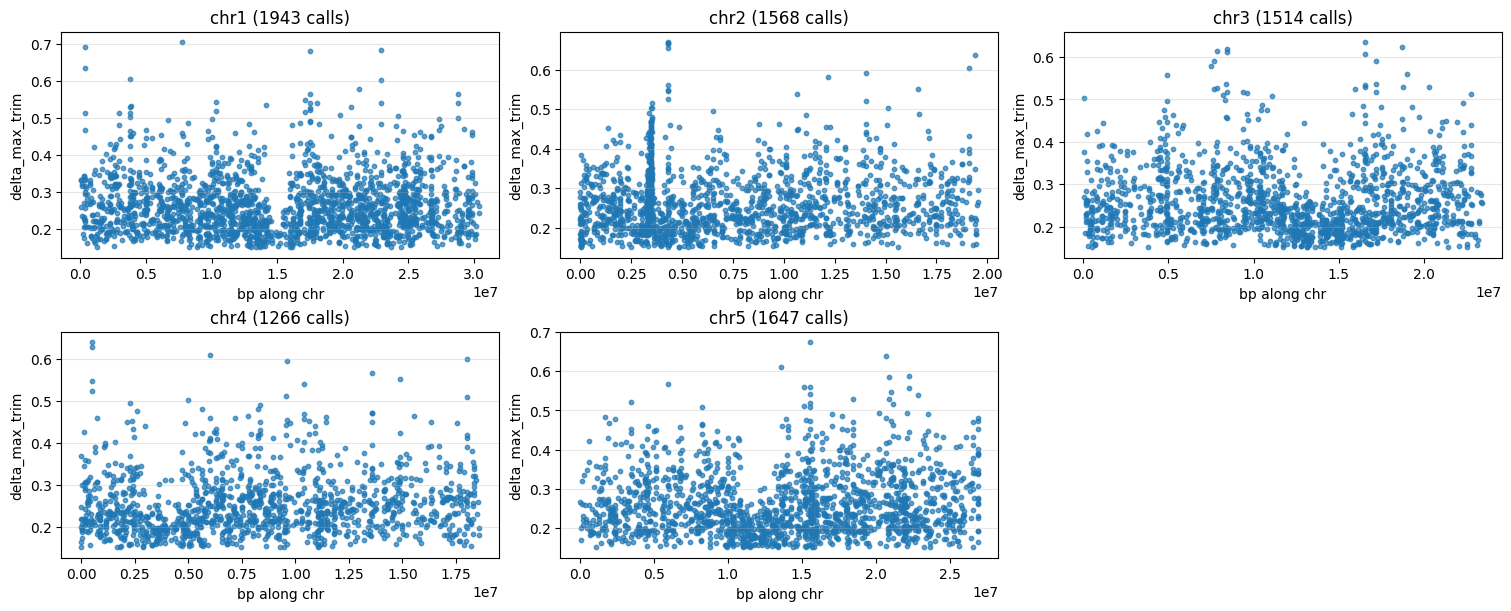

In [125]:
plot_calls_per_chr(calls)

In [10]:
import numpy as np

summary = {
    'n_tested': len(dmw),
    'n_called': len(calls),
    'call_rate_%': 100*len(calls)/max(len(dmw),1),
    'median_delta_trim_called': float(calls['delta_max_trim'].median()),
    '% LOCO<=0.05 among calls': float((calls['p_loco']<=0.05).mean()*100),
    '% neighbor>=1 among calls': float((calls['neighbor_support']>=1).mean()*100),
    'min(m_hi,m_lo) median': float(np.minimum(calls['m_hi'], calls['m_lo']).median())
}
summary


{'n_tested': 304690,
 'n_called': 7207,
 'call_rate_%': 2.3653549509337357,
 'median_delta_trim_called': 0.25382365432208726,
 '% LOCO<=0.05 among calls': 83.19689191064244,
 '% neighbor>=1 among calls': 100.0,
 'min(m_hi,m_lo) median': 22.0}

In [19]:
dmw[dmw['reason']=='ok']

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,X2_loco,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category
7,1,24301,24400,63.303077,16,0.323758,0,15,0.235239,15,...,33.888008,15.0,1.536786,5.201946e-04,1.064678e-01,6.429773e-03,1,True,ok,euc_gene
20,1,25801,25900,68.401063,16,0.283734,0,16,0.233424,9,...,58.003879,15.0,1.536786,1.649916e-04,9.844080e-04,2.425366e-03,2,False,ok,euc_gene
27,1,26601,26700,54.791427,16,0.340057,0,12,0.204524,12,...,27.864254,15.0,1.536786,3.231771e-03,2.558146e-01,2.900470e-02,2,True,ok,euc_gene
124,1,117101,117200,95.418897,16,0.454657,15,0,0.324092,15,...,69.541184,15.0,1.536786,2.317766e-07,6.989049e-05,7.101292e-06,1,False,ok,euc_gene
125,1,117201,117300,209.579299,16,0.469321,16,0,0.315957,16,...,130.321252,15.0,1.536786,0.000000e+00,9.155010e-12,0.000000e+00,1,False,ok,euc_gene
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304472,5,15152401,15152500,76.102981,16,0.345352,15,2,0.291096,0,...,62.357804,15.0,1.544736,2.998746e-05,3.989609e-04,1.631343e-03,1,False,ok,het_te
304508,5,15182201,15182300,124.173308,16,0.394110,16,7,0.264723,7,...,102.892617,15.0,1.544736,1.418309e-10,1.782187e-08,4.899795e-08,1,False,ok,het_te
304531,5,15203801,15203900,73.960816,16,0.356692,15,10,0.289099,10,...,61.158534,15.0,1.544736,4.961880e-05,5.225181e-04,2.429303e-03,1,False,ok,het_te
304627,5,15259701,15259800,70.739222,16,0.413612,8,6,0.340276,6,...,58.261694,15.0,1.544736,1.047749e-04,9.935832e-04,4.410364e-03,1,False,ok,het_te


In [31]:
import numpy as np
import pandas as pd

def select_dmws_q(
    dmw,                      # your dmw_robust table
    q_alpha=0.05,             # FDR threshold (loosen to 0.05 if you want)
    p_loco_alpha=0.05,        # LOCO robustness
    delta_trim_min=0.15,      # robust effect size
    # main path
    neighbor_min_main=1,
    m_hi_floor=7, m_lo_floor=10,
    # isolated strong (rescue)
    rescue_delta=0.255, rescue_m_hi=7, rescue_m_lo=40,
    # neighbor-backed moderate
    neighbor_min_consensus=2, m_floor_consensus=15
):
    dmw = dmw.copy()
    base = ((dmw.qval <= q_alpha) &
            (dmw.p_loco <= p_loco_alpha) &
            (dmw.delta_max_trim >= delta_trim_min))
    main = (base & (dmw.neighbor_support >= neighbor_min_main) &
            (dmw.m_hi >= m_hi_floor) & (dmw.m_lo >= m_lo_floor))
    rescue = (base & (dmw.delta_max_trim >= rescue_delta) &
              (dmw.m_hi >= rescue_m_hi) & (dmw.m_lo >= rescue_m_lo))
    consensus = (base & (dmw.neighbor_support >= neighbor_min_consensus) &
                 (dmw.m_hi >= m_floor_consensus) & (dmw.m_lo >= m_floor_consensus))

    reason = np.full(len(dmw), 'none', object)
    reason[consensus.to_numpy()] = 'consensus_neighbors'
    reason[rescue.to_numpy()]    = 'rescue_isolated'
    reason[main.to_numpy()]      = 'main'
    dmw['call_reason'] = reason

    calls_new = dmw.loc[main | rescue | consensus].copy()
    return calls_new


In [32]:
calls = select_dmws_q(dmw)
calls

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category,call_reason
85,1,77801,77900,283.205748,16,0.509852,16,0,0.258787,16,...,15.0,1.536786,0.000000e+00,1.479381e-03,0.000000e+00,0,False,no_neighbor_support,euc_gene,rescue_isolated
125,1,117201,117300,209.579299,16,0.469321,16,0,0.315957,16,...,15.0,1.536786,0.000000e+00,9.155010e-12,0.000000e+00,1,False,ok,euc_gene,main
129,1,121701,121800,121.351245,16,0.345870,4,16,0.321142,9,...,15.0,1.536786,2.556039e-10,7.882232e-08,1.349449e-08,1,False,ok,euc_gene,main
142,1,123101,123200,60.386475,16,0.280947,0,9,0.235865,9,...,15.0,1.536786,9.862091e-04,2.243899e-02,1.093957e-02,1,False,ok,euc_gene,main
294,1,243401,243500,69.454337,16,0.201690,4,9,0.186608,0,...,15.0,1.536786,1.295724e-04,1.617305e-02,1.967793e-03,2,False,weak_effect,euc_gene,main
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304611,5,15242801,15242900,77.878127,16,0.302944,13,12,0.154973,12,...,15.0,1.544736,1.968215e-05,3.571681e-02,1.171208e-03,2,False,weak_effect,het_te,main
304613,5,15243001,15243100,86.855885,16,0.244768,8,9,0.176046,12,...,15.0,1.544736,2.232159e-06,2.235987e-03,1.974125e-04,2,False,weak_effect,het_te,main
304627,5,15259701,15259800,70.739222,16,0.413612,8,6,0.340276,6,...,15.0,1.544736,1.047749e-04,9.935832e-04,4.410364e-03,1,False,ok,het_te,main
304628,5,15259801,15259900,67.105317,16,0.465839,5,4,0.305060,4,...,15.0,1.544736,2.397276e-04,1.577884e-02,8.303919e-03,2,False,ok,het_te,main


In [33]:
calls[(calls['start']>=21688700) & (calls['chr']==5)]

,chr,start,end,X2,df,delta_max,hi_cluster,lo_cluster,delta_max_trim,top_cluster,...,df_loco,phi,pval,p_loco,qval,neighbor_support,dominance_blocked,reason,category,call_reason
127100,5,21689801,21689900,92.114427,16,0.502153,15,7,0.248038,7,...,15.0,1.536786,5.357659e-07,7.047200e-03,1.515253e-05,2,False,ok,euc_gene,main
127101,5,21689901,21690000,61.347242,16,0.327902,15,7,0.213495,7,...,15.0,1.536786,8.000215e-04,1.944955e-02,9.205267e-03,2,False,ok,euc_gene,main
127104,5,21690501,21690600,76.075976,16,0.312061,6,7,0.200081,7,...,15.0,1.536786,2.749782e-05,4.242233e-03,5.090811e-04,1,False,ok,euc_gene,main
127109,5,21691101,21691200,87.398674,16,0.475944,14,4,0.328634,4,...,15.0,1.536786,1.745958e-06,4.194824e-04,4.367727e-05,0,False,no_neighbor_support,euc_gene,rescue_isolated
127119,5,21701401,21701500,143.198546,15,0.618520,15,7,0.269390,15,...,14.0,1.536786,2.520206e-13,8.586784e-09,2.111532e-11,0,False,no_neighbor_support,euc_gene,rescue_isolated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187470,5,23283001,23283100,71.822614,16,0.298224,7,4,0.152495,4,...,15.0,1.527399,6.754499e-05,4.346074e-02,1.951440e-03,1,False,weak_effect,euc_te,main
187471,5,23283101,23283200,130.598537,16,0.545234,16,4,0.413084,4,...,15.0,1.527399,1.670153e-11,8.802223e-07,2.531003e-09,1,False,ok,euc_te,main
187473,5,23309701,23309800,71.122098,16,0.486914,9,4,0.436264,12,...,15.0,1.527399,7.960834e-05,1.232438e-03,2.237406e-03,0,False,no_neighbor_support,euc_te,rescue_isolated
187577,5,24136701,24136800,74.568676,16,0.446024,14,9,0.346827,2,...,15.0,1.527399,3.527046e-05,7.212871e-04,1.148513e-03,1,False,ok,euc_te,main


In [34]:
calls.to_pickle("./data/calls_loose.pkl")